# 1. Predict PCD subtypes

In [1]:
## Import libraries 
import os
import pandas as pd
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
## Set working directory
# os.chdir("/Path/To/Your/Working Directory/") 
dir = 'Output/1-Predict_PCD_subtype/'
os.makedirs(dir, exist_ok = True)

In [3]:
## Configuration
Model = xgb.XGBClassifier()
Model.load_model("Utility/Model.model")
Mapping = {0: "PCD-P", 1: "PCD-PN", 2: "PCD-NF", 3: "PCD-FA", 4: "PCD-A"}
cmap = {"PCD-P": "#fdcc83", "PCD-PN": "#f6afb0", "PCD-NF": "#c27cd6", "PCD-FA": "#71b3a8", "PCD-A": "#6292b0"}

## 1. Prepare Data

In [4]:
## If you start from a log2-transformed tpm-quantified expression matrix:
# Expr_raw = pd.read_csv('Path/To/Your/Data.tsv', delimiter = '\t')
# Expr_raw = Expr_raw.set_index("Gene")
# # Step 1: Select PCD genes
# PCD_Gene = pd.read_csv('Utility/PCD_Gene.tsv', delimiter = '\t')
# Expr_PCD = Expr_raw.loc[list(set(Expr_raw.index) & set(PCD_Gene['Gene_Symbol']))].T
# Expr_PCD.index.name = 'ID_sample'
# # Step 2: Median scaling
# from sklearn.preprocessing import RobustScaler
# Expr = pd.DataFrame(RobustScaler().fit_transform(Expr_PCD), index = Expr_PCD.index, columns = Expr_PCD.columns)
# Expr

In [5]:
# Load the PCD Expression data (Make sure the expression matrix have been median-scaled)
Expr = pd.read_csv('Data/CPTAC/PCD_Expr.tsv', delimiter = '\t')
Expr = Expr.set_index("ID_sample")

## 2. Infer subtypes

In [6]:
## Predict
Expr = Expr.reindex(columns = Model.get_booster().feature_names)
Predicted_subtype = Model.predict(Expr)
Predicted_subtype_proba = Model.predict_proba(Expr)

Prediction = pd.DataFrame(Predicted_subtype, columns=['PCD Subtype'])
Prediction['PCD Subtype'] = Prediction['PCD Subtype'].map(Mapping)
for i in range(5):
    Prediction['Probability_' + Mapping[i]] = Predicted_subtype_proba[:, i]
Prediction["Max_Probability"] = Prediction[[c for c in Prediction.columns if c.startswith("Probability_")]].max(axis = 1)
Prediction['ID_sample'] = Expr.index
Prediction = Prediction.set_index("ID_sample")

Prediction.to_csv(dir + 'Prediction.tsv', sep = '\t', index = True)
Prediction

,PCD Subtype,Probability_PCD-P,Probability_PCD-PN,Probability_PCD-NF,Probability_PCD-FA,Probability_PCD-A,Max_Probability
ID_sample,,,,,,,
25-R,PCD-FA,0.007633,0.065130,0.030960,0.890813,0.005464,0.890813
350-R,PCD-P,0.982980,0.005903,0.007642,0.002936,0.000539,0.982980
345-R,PCD-A,0.113959,0.187869,0.009801,0.058748,0.629623,0.629623
349-R,PCD-FA,0.001557,0.172546,0.055527,0.758645,0.011726,0.758645
26-R,PCD-PN,0.017353,0.782473,0.030431,0.138401,0.031342,0.782473
...,...,...,...,...,...,...,...
cb6b2cc0-d840-4968-837c-b3b833adfc52,PCD-NF,0.057347,0.324236,0.561310,0.027846,0.029261,0.561310
da8993a8-d120-43a6-9a93-65aced75ed19,PCD-PN,0.323390,0.608910,0.035760,0.025779,0.006161,0.608910
907d39d0-7e81-4d83-88dc-26cce0e7a0a1,PCD-PN,0.031471,0.721626,0.161776,0.073419,0.011709,0.721626


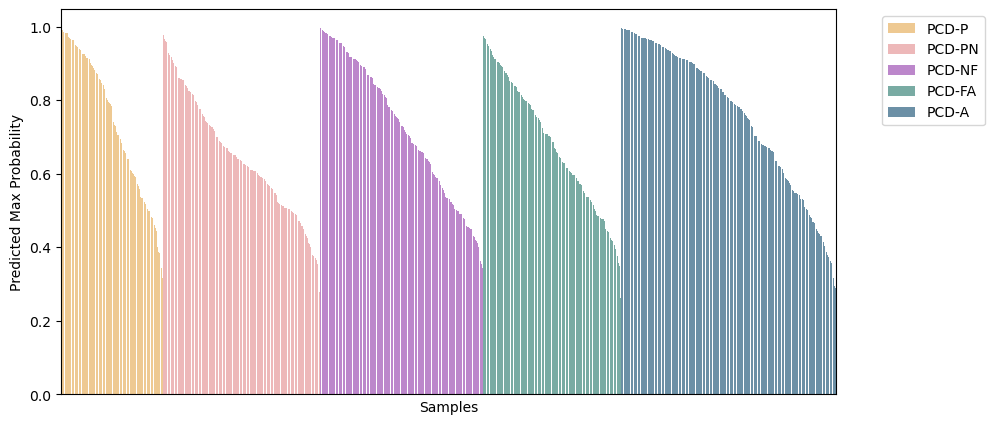

In [7]:
## Plot probability
Prediction["PCD Subtype"] = pd.Categorical(Prediction["PCD Subtype"], categories = ["PCD-P", "PCD-PN", "PCD-NF", "PCD-FA", "PCD-A"], ordered = True)
Prediction = Prediction.sort_values(by = ["PCD Subtype", "Max_Probability"], ascending = [True, False])
Prediction.index = pd.Categorical(Prediction.index, categories = Prediction.index, ordered = True)
plt.figure(figsize=(10, 5))
sns.barplot(
    data = Prediction,
    x = Prediction.index,
    y = "Max_Probability",
    hue = "PCD Subtype",
    dodge = False,
    palette = cmap
)
plt.xlabel("Samples")
plt.ylabel("Predicted Max Probability")
plt.xticks([], [])
plt.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.savefig(dir + 'Prediction_probability.png', dpi = 300, bbox_inches = 'tight')
plt.show()